Instrucciones iniciales que usaré en el proyecto

In [ ]:
# Celda 1: instalar dependencias
!pip install -q transformers datasets rouge-score nltk sentencepiece accelerate gradio

  Preparing metadata (setup.py) ... done


In [ ]:
# Celda 2: imports generales y configuración
import os
import random
import math
from pathlib import Path
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import nltk
nltk.download('punkt')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Device: cuda


# Preparación del dataset (BBC) y splits

In [ ]:
# Celda 3: cargar y preparar

import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text) # Elimina saltos de línea y espacios extra
    text = re.sub(r'[^\w\s]', '', text) # Elimina puntuación innecesaria para el entrenamiento inicial
    return text.strip()

# Cargar y limpiar
raw = load_dataset("gopalkalpande/bbc-news-summary")
df = raw["train"].to_pandas()[["Articles", "Summaries"]].rename(columns={"Articles":"text", "Summaries":"summary"})

df['text'] = df['text'].apply(clean_text)
df['summary'] = df['summary'].apply(clean_text)

# raw = load_dataset("gopalkalpande/bbc-news-summary")
# df = raw["train"].to_pandas()[["Articles", "Summaries"]].rename(columns={"Articles":"text", "Summaries":"summary"})
print("Total examples:", len(df))
df.head()

# train/val/test split
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.10, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.10, random_state=42)
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

bbc-news-summary.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/2224 [00:00<?, ? examples/s]

Total examples: 2224
Train: 1800 Val: 201 Test: 223


# Exploración de Análisis de Datos (EDA)

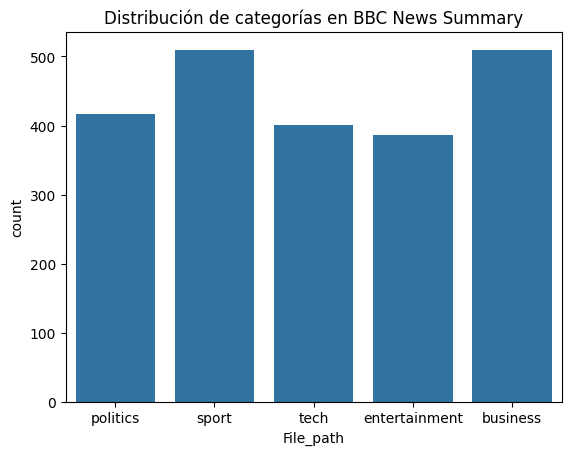

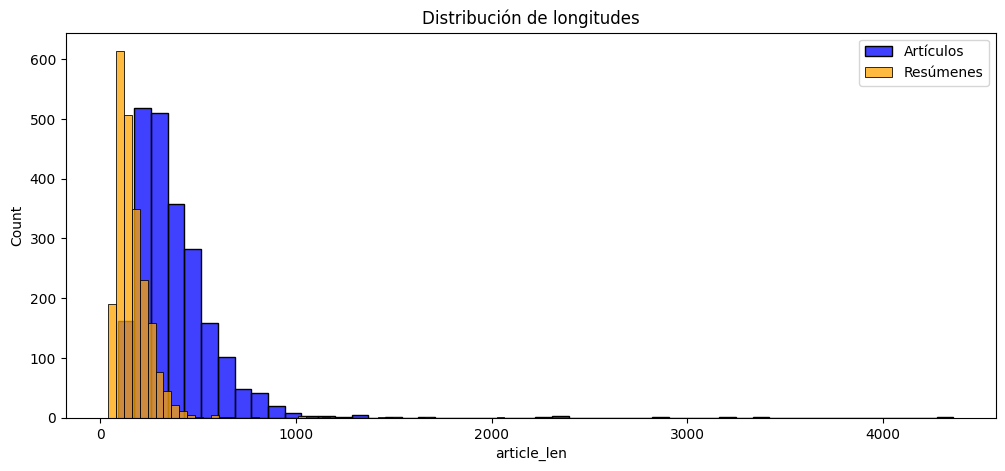

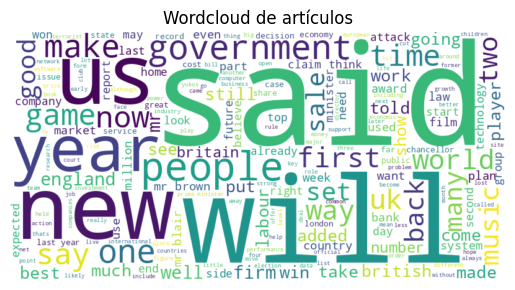

In [ ]:
# Celda 4: EDA

import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

df1 = raw["train"].to_pandas()

# Distribución por categorías
sns.countplot(data=df1, x="File_path") # Removed as 'File_path' column does not exist
plt.title("Distribución de categorías en BBC News Summary")
plt.show()

# Longitud de artículos y resúmenes
df["article_len"] = df["text"].apply(lambda x: len(x.split()))
df["summary_len"] = df["summary"].apply(lambda x: len(x.split()))

plt.figure(figsize=(12,5))
sns.histplot(df["article_len"], bins=50, color="blue", label="Artículos")
sns.histplot(df["summary_len"], bins=50, color="orange", label="Resúmenes")
plt.legend()
plt.title("Distribución de longitudes")
plt.show()

# Wordcloud de artículos
text_all = " ".join(df["text"].sample(200))
wc = WordCloud(width=800, height=400, background_color="white").generate(text_all)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud de artículos")
plt.show()

# Tokenizador simple (word-level) y Dataset PyTorch

In [ ]:
# Celda 5: Tokenizador
from transformers import AutoTokenizer

# 1. Cargar Tokenizador Profesional (GPT-2)
# Usamos GPT-2 porque su tokenizador (BPE) es muy bueno rompiendo palabras desconocidas
checkpoint = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

# 2. Arreglo importante: GPT-2 no tiene token de relleno (pad) por defecto
tokenizer.pad_token = tokenizer.eos_token

# 3. Definimos el tamaño del vocabulario para tus modelos
# IMPORTANTE: Ahora vocab_size será el tamaño real del tokenizador (aprox 50257)
vocab_size = len(tokenizer)
stoi = tokenizer.get_vocab() # Por si alguna función aún pide 'stoi'
itos = {i: t for t, i in stoi.items()} # Por si alguna función aún pide 'itos'

# 4. Variables de compatibilidad (para que no rompa tu código de abajo)
# En lugar de usar stoi/itos, el modelo usará el tamaño real del vocabulario de GPT-2
INPUT_DIM = len(tokenizer)
OUTPUT_DIM = len(tokenizer)
PAD_IDX = tokenizer.pad_token_id

print(f"Vocabulario Cargado: {INPUT_DIM} tokens (Subword Tokenization)")
print(f"Ejemplo: 'Battery' -> {tokenizer.encode('Battery')}")
print(f"Ejemplo: 'Batery' (mal escrito) -> {tokenizer.encode('Batery')} (Lo rompe en trozos entendibles)")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Vocabulario Cargado: 50257 tokens (Subword Tokenization)
Ejemplo: 'Battery' -> [47006]
Ejemplo: 'Batery' (mal escrito) -> [33, 729, 88] (Lo rompe en trozos entendibles)


In [ ]:
# Celda 6: Actualización clase Dataset, Helpers y DataLoaders
from torch.utils.data import Dataset, DataLoader
import torch

class BBCDataset(Dataset):
    def __init__(self, df, tokenizer, max_len_text=512, max_len_summary=128):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len_text = max_len_text
        self.max_len_summary = max_len_summary

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row['text'])
        summary = str(row['summary'])

        # 1. Tokenizar el Texto (Noticia)
        input_enc = self.tokenizer(
            text,
            max_length=self.max_len_text,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )

        # 2. Tokenizar el Resumen (Target)
        target_enc = self.tokenizer(
            summary,
            max_length=self.max_len_summary,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )

        return {
            "text": input_enc["input_ids"].squeeze(),
            "summary": target_enc["input_ids"].squeeze()
        }

# --- HELPERS DE CODIFICACIÓN ---
def encode(text, max_len=512):
    return tokenizer.encode(text, truncation=True, max_length=max_len)

def decode(ids, skip_special_tokens=True):
    if torch.is_tensor(ids):
        ids = ids.tolist()
    return tokenizer.decode(ids, skip_special_tokens=skip_special_tokens)

# --- FUNCIÓN COLLATE PARA EL DATALOADER ---
def collate_fn(batch):
    # Extrae los tensores ya tokenizados por el Dataset
    texts = [item["text"] for item in batch]
    summaries = [item["summary"] for item in batch]

    # Apila los tensores en lotes (batches)
    # Como ya vienen con padding desde el Dataset, stack es suficiente
    texts_padded = torch.stack(texts)
    summaries_padded = torch.stack(summaries)

    return texts_padded, summaries_padded

# --- CREACIÓN DE DATASETS Y LOADERS ---
train_ds = BBCDataset(train_df, tokenizer,max_len_text=256, max_len_summary=64)
val_ds   = BBCDataset(val_df, tokenizer, max_len_text=256, max_len_summary=64)
test_ds  = BBCDataset(test_df, tokenizer, max_len_text=256, max_len_summary=64)

# Definición de Loaders (puedes ajustar el batch_size si tienes errores de memoria)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False, collate_fn=collate_fn)

print(f"Tamaño del vocabulario: {len(tokenizer)}")

Tamaño del vocabulario: 50257


# Modelo Seq2Seq: GRU + Atención (Luong)

In [ ]:
class EncoderGRU(nn.Module):
    def __init__(self, vocab_size, emb_size=256, hid_size=512, num_layers=1, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size, padding_idx=PAD_IDX)
        self.gru = nn.GRU(emb_size, hid_size, num_layers=num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hid_size*2, hid_size)  # combinar bi-direccional
        self.dropout = nn.Dropout(dropout)
    def forward(self, src, src_len=None):
        emb = self.dropout(self.embedding(src))  # (B, S, E)
        outputs, hidden = self.gru(emb)  # outputs (B, S, 2*H)
        # combinar hidden states (num_layers*2, B, H) -> (num_layers, B, 2H) then project
        # Para simplicidad: tomar últimos estados y fusionarlos
        # hidden: (num_layers*2, B, H)
        # concatenamos forward+back for last layer
        h_forward = hidden[-2,:,:]
        h_backward = hidden[-1,:,:]
        h = torch.tanh(self.fc(torch.cat([h_forward, h_backward], dim=1)))  # (B, H)
        # expand to (1, B, H) as initial decoder hidden
        return outputs, h.unsqueeze(0)

class LuongAttention(nn.Module):
    # Modified __init__ to accept encoder_hid_size and decoder_hid_size
    def __init__(self, encoder_hid_size, decoder_hid_size):
        super().__init__()
        # Linear layer now projects from encoder output dim (bidirectional) to decoder hidden dim
        self.linear = nn.Linear(encoder_hid_size * 2, decoder_hid_size, bias=False)
    def forward(self, dec_hidden, enc_outputs):
        # dec_hidden: (B, dec_hid_size) ; enc_outputs: (B, S, 2*encoder_hid_size)
        # project enc outputs to decoder_hid_size
        proj = self.linear(enc_outputs)  # (B, S, decoder_hid_size)
        scores = torch.bmm(proj, dec_hidden.unsqueeze(2)).squeeze(2)  # (B, S)
        attn = torch.softmax(scores, dim=1)
        context = torch.bmm(attn.unsqueeze(1), enc_outputs).squeeze(1)  # (B, 2*encoder_hid_size)
        return context, attn

class DecoderGRU(nn.Module):
    def __init__(self, vocab_size, emb_size=256, enc_hid_size=512, dec_hid_size=512, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size, padding_idx=PAD_IDX)
        self.gru = nn.GRU(emb_size + enc_hid_size*2, dec_hid_size, batch_first=True)  # input: emb + context
        # Modified instantiation of LuongAttention to pass both enc_hid_size and dec_hid_size
        self.attn = LuongAttention(enc_hid_size, dec_hid_size)
        self.fc_out = nn.Linear(dec_hid_size + enc_hid_size*2 + emb_size, vocab_size)
        self.dropout = nn.Dropout(dropout)
    def forward(self, input_step, last_hidden, enc_outputs):
        # input_step: (B, 1)
        emb = self.dropout(self.embedding(input_step))  # (B,1,E)
        # compute context with attention (use last_hidden[-1] as dec_hidden)
        dec_hidden = last_hidden[-1]  # (B, H)
        context, attn = self.attn(dec_hidden, enc_outputs)  # context (B, 2H)
        # concatenate emb and context and feed to gru
        gru_input = torch.cat([emb, context.unsqueeze(1)], dim=2)  # (B,1, E+2H)
        output, hidden = self.gru(gru_input, last_hidden)  # output (B,1,H)
        output = output.squeeze(1)  # (B,H)
        emb_s = emb.squeeze(1)
        pred = self.fc_out(torch.cat([output, context, emb_s], dim=1))  # (B, V)
        return pred, hidden, attn

class Seq2SeqGRU(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    def forward(self, src, trg=None, teacher_forcing_ratio=0.5, max_len=64):
        enc_outputs, dec_hidden = self.encoder(src)
        batch_size = src.size(0)
        outputs = []
        input_token = torch.full((batch_size,1), SOS_IDX, dtype=torch.long, device=src.device)
        hidden = dec_hidden
        for t in range(max_len):
            logits, hidden, attn = self.decoder(input_token, hidden, enc_outputs)
            outputs.append(logits.unsqueeze(1))
            top1 = logits.argmax(1).unsqueeze(1)
            if trg is not None and random.random() < teacher_forcing_ratio:
                input_token = trg[:,t].unsqueeze(1) if t < trg.size(1) else top1
            else:
                input_token = top1
        outputs = torch.cat(outputs, dim=1)
        return outputs

# instanciar
enc = EncoderGRU(vocab_size, emb_size=256, hid_size=512, num_layers=2, dropout=0.2).to(device)
dec = DecoderGRU(vocab_size, emb_size=256, enc_hid_size=512, dec_hid_size=512, dropout=0.2).to(device)
model_gru = Seq2SeqGRU(enc, dec).to(device)
print("GRU model params:", sum(p.numel() for p in model_gru.parameters() if p.requires_grad))

GRU model params: 126737233


# Training loop para Seq2Seq GRU

In [ ]:
# Celda 7: entrenamiento GRU
import torch.optim as optim
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
# optimizer = optim.Adam(model_gru.parameters(), lr=1e-3)
optimizer = optim.Adam(model_gru.parameters(), lr=5e-4)

# Definir SOS y EOS IDs. Para GPT-2, el token EOS es a menudo usado para ambos.
SOS_IDX = tokenizer.eos_token_id
EOS_IDX = tokenizer.eos_token_id

def train_epoch(model, loader, optimizer, criterion, clip=1.0):
    model.train()
    total_loss = 0
    for batch in loader:
        # batch es una tupla (textos_padded, summaries_padded) de collate_fn
        src = batch[0].to(device)
        trg = batch[1].to(device)
        optimizer.zero_grad()
        outputs = model(src, trg, teacher_forcing_ratio=0.5, max_len=trg.size(1))
        # outputs: (B, T, V)
        loss = criterion(outputs.view(-1, outputs.size(-1)), trg.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            # batch es una tupla (textos_padded, summaries_padded) de collate_fn
            src = batch[0].to(device)
            trg = batch[1].to(device)
            outputs = model(src, None, teacher_forcing_ratio=0.0, max_len=trg.size(1))
            loss = criterion(outputs.view(-1, outputs.size(-1)), trg.view(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

# Entrenamiento corto de ejemplo (ajusta epochs y batch según GPU)
n_epochs = 10 # Se aumenta de 4 a 10
for epoch in range(1, n_epochs+1):
    tr_loss = train_epoch(model_gru, train_loader, optimizer, criterion)
    val_loss = eval_epoch(model_gru, val_loader, criterion)
    print(f"[GRU] Epoch {epoch} TrainLoss={tr_loss:.4f} ValLoss={val_loss:.4f}")
# Guardar checkpoint
torch.save(model_gru.state_dict(), "gru_s2s_checkpoint.pt")

[GRU] Epoch 1 TrainLoss=4.9697 ValLoss=7.6792
[GRU] Epoch 2 TrainLoss=4.5624 ValLoss=7.8242
[GRU] Epoch 3 TrainLoss=4.3595 ValLoss=7.8994
[GRU] Epoch 4 TrainLoss=4.1613 ValLoss=7.9230
[GRU] Epoch 5 TrainLoss=4.0194 ValLoss=7.9846
[GRU] Epoch 6 TrainLoss=3.9172 ValLoss=8.1051
[GRU] Epoch 7 TrainLoss=3.7685 ValLoss=8.1525
[GRU] Epoch 8 TrainLoss=3.6496 ValLoss=8.1715
[GRU] Epoch 9 TrainLoss=3.5080 ValLoss=8.3032
[GRU] Epoch 10 TrainLoss=3.4097 ValLoss=8.3168


# Inferencia (GRU) — decodificación greedy

In [ ]:
# Celda 8: inferencia GRU (con Beam Search)
def generate_gru(model, src_text: str, stoi, itos, max_len=64, num_beams=5, skip_special_tokens=True):
    model.eval()
    ids = encode(src_text, max_len=512)
    src = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        enc_outputs, dec_hidden = model.encoder(src)

        # Greedy decoding (num_beams=1) with no-repeat-ngram_size=2 logic
        if num_beams == 1:
            generated_ids = [SOS_IDX]
            last_generated_token_id = SOS_IDX # Keep track of the last token generated
            hidden = dec_hidden
            for t in range(max_len):
                input_token = torch.tensor([[generated_ids[-1]]], dtype=torch.long, device=src.device)
                logits, hidden, _ = model.decoder(input_token, hidden, enc_outputs)

                # Get probabilities and set probability of repeating the last token to -inf
                log_probs = torch.log_softmax(logits, dim=-1).squeeze(0)
                if len(generated_ids) > 1: # Don't apply this for the very first token after SOS
                    log_probs[last_generated_token_id] = -float('inf')

                next_token = torch.argmax(log_probs).item()

                if skip_special_tokens and next_token == EOS_IDX:
                    break

                generated_ids.append(next_token)
                last_generated_token_id = next_token # Update last generated token

            best_sequence = generated_ids

        # Beam search logic (original, but can also apply no-repeat-ngram here if desired)
        else:
            beams = [(0.0, [SOS_IDX], dec_hidden)]
            finished_beams = []

            for _ in range(max_len):
                new_beams = []
                for log_prob, seq, hidden_state in beams:
                    if seq[-1] == EOS_IDX and len(seq) > 1:
                        finished_beams.append((log_prob, seq))
                        continue

                    input_token = torch.tensor([[seq[-1]]], device=device)
                    logits, new_hidden, _ = model.decoder(input_token, hidden_state, enc_outputs)

                    log_probs = torch.log_softmax(logits, dim=-1).squeeze(0)

                    # Apply no-repeat-ngram_size=2 logic (prevent immediate repetition) for beam search
                    if len(seq) > 1: # Don't penalize for the first token after SOS
                        log_probs[seq[-1]] = -float('inf') # Set probability to -inf for repeating the last token

                    top_log_probs, top_indices = torch.topk(log_probs, num_beams)

                    for i in range(num_beams):
                        next_token_id = top_indices[i].item()
                        next_log_prob = top_log_probs[i].item()
                        new_beams.append((log_prob + next_log_prob, seq + [next_token_id], new_hidden))

                beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:num_beams]

                if len(finished_beams) >= num_beams:
                     pass

            finished_beams.extend(beams)
            best_sequence = sorted(finished_beams, key=lambda x: x[0], reverse=True)[0][1]

        if skip_special_tokens:
            if best_sequence[0] == SOS_IDX:
                best_sequence = best_sequence[1:]
            if EOS_IDX in best_sequence:
                best_sequence = best_sequence[:best_sequence.index(EOS_IDX)]

    return decode(best_sequence, skip_special_tokens=skip_special_tokens)

# Prueba rápida
sample = train_df.iloc[0]["text"]
print("GRU summary (Greedy) - decoded:", generate_gru(model_gru, sample, stoi, itos, max_len=80, num_beams=1))
print("GRU summary (Beam Search) - decoded:", generate_gru(model_gru, sample, stoi, itos, max_len=80, num_beams=5))
print("Reference:", train_df.iloc[0]["summary"])

GRU summary (Greedy) - raw tokens: <|endoftext|>the ministry said the ministry of the unfavourable domestic and ministry unfavourable domestic and employment to dog the ministry of the ministry spill the ministry spill the ministry spill the ministry spill the ministry spill the ministry ofinternal and employment effect and employment effect and the ministry saidinternal and external the ministry spill the ministry ofinternal and external and ministry and ministry and ministry and ministry and ministry and ministry and ministry and
GRU summary (Beam Search) - raw tokens: <|endoftext|>the ministry is likely to be the unfavourable domestic and ministry unfavourable domestic and employment to dog the ministry of the ministry saidgiven the ministry spill likely to adverse effects the ministry ofinternal and employment effect and employment effect to adverse effects the ministry ofinternal and external the ministry saidinternal the ministry saidinternal and external the ministry spill the m

# Transformer pequeño desde cero (PyTorch nn.Transformer)

In [ ]:
# Celda 9: Transform Model
import torch.nn as nn
import torch
import math

class TransformerSumm(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=8, num_encoder_layers=3, num_decoder_layers=3, dim_feedforward=512, dropout=0.1):
        super().__init__()
        self.model_type = 'Transformer'
        self.tok_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_emb = nn.Embedding(1024, d_model)
        self.transformer = nn.Transformer(d_model, nhead, num_encoder_layers, num_decoder_layers, dim_feedforward, dropout, batch_first=True)
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.d_model = d_model

    def forward(self, src, tgt, src_key_padding_mask=None, tgt_key_padding_mask=None):
        # src, tgt: (B, S)
        # src_mask = None # src_mask is for causality, not padding. Encoder doesn't need causal mask.
        tgt_mask = self.transformer.generate_square_subsequent_mask(tgt.size(1)).to(tgt.device)

        src_pos = torch.arange(0, src.size(1), device=src.device).unsqueeze(0)
        tgt_pos = torch.arange(0, tgt.size(1), device=tgt.device).unsqueeze(0)

        src_emb = self.tok_emb(src) * math.sqrt(self.d_model) + self.pos_emb(src_pos)
        tgt_emb = self.tok_emb(tgt) * math.sqrt(self.d_model) + self.pos_emb(tgt_pos)

        out = self.transformer(src_emb, tgt_emb, tgt_mask=tgt_mask, src_key_padding_mask=src_key_padding_mask, tgt_key_padding_mask=tgt_key_padding_mask)
        return self.fc_out(out)

# Instanciar y mover a device
model_tr = TransformerSumm(vocab_size, d_model=256, nhead=8, num_encoder_layers=2, num_decoder_layers=2).to(device)
print("Transformer params:", sum(p.numel() for p in model_tr.parameters() if p.requires_grad))

Transformer params: 28680785


In [ ]:
# Celda 10: simple training loop para transformer (teacher forcing usando tgt inputs)
optim_tr = optim.Adam(model_tr.parameters(), lr=1e-4)
criterion_tr = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

def train_epoch_tr(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        # 'batch' es una tupla (textos_padded, summaries_padded) de collate_fn
        src = batch[0].to(device) # Acceder al texto de entrada (input_ids)
        labels = batch[1].to(device) # Acceder a las etiquetas (summaries)

        # prepare decoder input as labels shifted right
        decoder_input = torch.cat([torch.full((labels.size(0),1), SOS_IDX, dtype=torch.long, device=device), labels[:,:-1]], dim=1)

        # Create masks
        src_key_padding_mask = (src == PAD_IDX)
        tgt_key_padding_mask = (decoder_input == PAD_IDX)

        optimizer.zero_grad()
        outputs = model(src, decoder_input, src_key_padding_mask=src_key_padding_mask, tgt_key_padding_mask=tgt_key_padding_mask)  # (B, T, V)
        loss = criterion(outputs.view(-1, outputs.size(-1)), labels.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch_tr(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            # 'batch' es una tupla (textos_padded, summaries_padded) de collate_fn
            src = batch[0].to(device) # Acceder al texto de entrada (input_ids)
            labels = batch[1].to(device) # Acceder a las etiquetas (summaries)
            decoder_input = torch.cat([torch.full((labels.size(0),1), SOS_IDX, dtype=torch.long, device=device), labels[:,:-1]], dim=1)

            # Create masks
            src_key_padding_mask = (src == PAD_IDX)
            tgt_key_padding_mask = (decoder_input == PAD_IDX)

            outputs = model(src, decoder_input, src_key_padding_mask=src_key_padding_mask, tgt_key_padding_mask=tgt_key_padding_mask)
            loss = criterion(outputs.view(-1, outputs.size(-1)), labels.view(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

# Entrenamiento pequeño como ejemplo
for epoch in range(1, 20): # Increased epochs from 4 to 10
    trl = train_epoch_tr(model_tr, train_loader, optim_tr, criterion_tr)
    vall = eval_epoch_tr(model_tr, val_loader, criterion_tr)
    print(f"[Transformer] Epoch {epoch} TrainLoss={trl:.4f} ValLoss={vall:.4f}")
torch.save(model_tr.state_dict(), "transformer_checkpoint.pt")

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


[Transformer] Epoch 1 TrainLoss=6.3677 ValLoss=6.8621
[Transformer] Epoch 2 TrainLoss=6.2006 ValLoss=6.8187
[Transformer] Epoch 3 TrainLoss=6.0658 ValLoss=6.7988
[Transformer] Epoch 4 TrainLoss=5.9407 ValLoss=6.7535
[Transformer] Epoch 5 TrainLoss=5.8188 ValLoss=6.7111
[Transformer] Epoch 6 TrainLoss=5.6976 ValLoss=6.6816
[Transformer] Epoch 7 TrainLoss=5.5811 ValLoss=6.6549
[Transformer] Epoch 8 TrainLoss=5.4655 ValLoss=6.6428
[Transformer] Epoch 9 TrainLoss=5.3522 ValLoss=6.6164
[Transformer] Epoch 10 TrainLoss=5.2401 ValLoss=6.6041
[Transformer] Epoch 11 TrainLoss=5.1263 ValLoss=6.5867
[Transformer] Epoch 12 TrainLoss=5.0162 ValLoss=6.5811
[Transformer] Epoch 13 TrainLoss=4.9085 ValLoss=6.5550
[Transformer] Epoch 14 TrainLoss=4.7974 ValLoss=6.5542
[Transformer] Epoch 15 TrainLoss=4.6940 ValLoss=6.5567
[Transformer] Epoch 16 TrainLoss=4.5910 ValLoss=6.5501
[Transformer] Epoch 17 TrainLoss=4.4848 ValLoss=6.5363
[Transformer] Epoch 18 TrainLoss=4.3818 ValLoss=6.5324
[Transformer] Epoch

In [ ]:
# Celda 11: inferencia transformer (greedy dec)
def generate_transformer(model, src_text, max_len=80, skip_special_tokens=True):
    model.eval()
    ids = encode(src_text, max_len=512)
    src = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)
    generated = [SOS_IDX]
    last_generated_token_id = SOS_IDX # Keep track of the last token generated

    with torch.no_grad():
        src_key_padding_mask = (src == PAD_IDX)
        for _ in range(max_len):
            tgt = torch.tensor(generated, dtype=torch.long).unsqueeze(0).to(device)
            out = model(src, tgt, src_key_padding_mask=src_key_padding_mask)  # (1, T, V)

            log_probs = torch.log_softmax(out[:, -1, :], dim=-1).squeeze(0)

            # Apply no-repeat-ngram_size=2 logic (prevent immediate repetition)
            if len(generated) > 1: # Don't penalize for the first token after SOS
                log_probs[last_generated_token_id] = -float('inf')

            next_token = torch.argmax(log_probs).item()

            if skip_special_tokens and next_token == EOS_IDX:
                break
            generated.append(next_token)
            last_generated_token_id = next_token # Update last generated token

    output_sequence = generated[1:] if skip_special_tokens else generated
    return decode(output_sequence, skip_special_tokens=skip_special_tokens)

print("Transformer summary - raw tokens:", generate_transformer(model_tr, train_df.iloc[0]["text"], max_len=80, skip_special_tokens=False))
print("Transformer summary - decoded:", generate_transformer(model_tr, train_df.iloc[0]["text"], max_len=80))

Transformer summary - raw tokens: <|endoftext|>the report said the european commission on its own has said it would be the european growth in its first time on its first time on its first time on its first time on its first time on its first time on its first time on its first time on its first time on its first quarter on its first time in the european said it will be more than a new low in
Transformer summary - decoded: the report said the european commission on its own has said it would be the european growth in its first time on its first time on its first time on its first time on its first time on its first time on its first time on its first time on its first time on its first quarter on its first time in the european said it will be more than a new low in


# Fine-tuning con Hugging Face: T5-small y BART-large-CNN

In [ ]:
# Celda 12: preparar dataset para HuggingFace Trainer
from transformers import T5TokenizerFast, T5ForConditionalGeneration, BartTokenizerFast, BartForConditionalGeneration
from datasets import Dataset

# Convertir pandas -> datasets.Dataset (col: text, summary)
train_hf = Dataset.from_pandas(train_df.reset_index(drop=True))
val_hf = Dataset.from_pandas(val_df.reset_index(drop=True))
test_hf = Dataset.from_pandas(test_df.reset_index(drop=True))

# Tokenizer T5
t5_tokenizer = T5TokenizerFast.from_pretrained("t5-small")
bart_tokenizer = BartTokenizerFast.from_pretrained("facebook/bart-large-cnn")

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

In [ ]:
# Celda 13: tokenization functions para T5 y BART
max_input = 512
max_output = 150

def preprocess_t5(batch):
    inputs = ["summarize: " + t for t in batch["text"]]
    model_inputs = t5_tokenizer(inputs, max_length=max_input, truncation=True, padding="max_length")
    labels = t5_tokenizer(batch["summary"], max_length=max_output, truncation=True, padding="max_length")
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

def preprocess_bart(batch):
    model_inputs = bart_tokenizer(batch["text"], max_length=max_input, truncation=True, padding="max_length")
    labels = bart_tokenizer(batch["summary"], max_length=max_output, truncation=True, padding="max_length")
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# map datasets (usa batched=True)
train_t5 = train_hf.map(preprocess_t5, batched=True, remove_columns=train_hf.column_names)
val_t5 = val_hf.map(preprocess_t5, batched=True, remove_columns=val_hf.column_names)
test_t5 = test_hf.map(preprocess_t5, batched=True, remove_columns=test_hf.column_names)

train_bart = train_hf.map(preprocess_bart, batched=True, remove_columns=train_hf.column_names)
val_bart = val_hf.map(preprocess_bart, batched=True, remove_columns=val_hf.column_names)
test_bart = test_hf.map(preprocess_bart, batched=True, remove_columns=test_hf.column_names)

Map:   0%|          | 0/1800 [00:00<?, ? examples/s]

Map:   0%|          | 0/201 [00:00<?, ? examples/s]

Map:   0%|          | 0/223 [00:00<?, ? examples/s]

Map:   0%|          | 0/1800 [00:00<?, ? examples/s]

Map:   0%|          | 0/201 [00:00<?, ? examples/s]

Map:   0%|          | 0/223 [00:00<?, ? examples/s]

In [ ]:
# Celda 14: Trainer para T5
from transformers import TrainingArguments, Trainer, DataCollatorForSeq2Seq

t5_model = T5ForConditionalGeneration.from_pretrained("t5-small").to(device)
data_collator_t5 = DataCollatorForSeq2Seq(t5_tokenizer, model=t5_model)

training_args_t5 = TrainingArguments(
    output_dir="t5_finetuned",
    num_train_epochs=2,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=200,
    fp16=torch.cuda.is_available(),
    push_to_hub=False,
)

trainer_t5 = Trainer(
    model=t5_model,
    args=training_args_t5,
    train_dataset=train_t5,
    eval_dataset=val_t5,
    data_collator=data_collator_t5,
    tokenizer=t5_tokenizer,
)

# Entrenar T5 (descomenta para ejecutar)
trainer_t5.train()
trainer_t5.save_model("t5_finetuned_model")

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

/tmp/ipython-input-121180776.py:21: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_t5 = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


Epoch,Training Loss,Validation Loss
1,0.972100,0.676297
2,0.866800,0.650916


In [ ]:
# Celda 15: Trainer para BART
bart_model = BartForConditionalGeneration.from_pretrained("facebook/bart-large-cnn").to(device)
data_collator_bart = DataCollatorForSeq2Seq(bart_tokenizer, model=bart_model)

training_args_bart = TrainingArguments(
    output_dir="bart_finetuned",
    num_train_epochs=2,
    per_device_train_batch_size=2,  # bart-large usa más memoria
    per_device_eval_batch_size=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    weight_decay=0.01,
    logging_steps=200,
    fp16=torch.cuda.is_available(),
    push_to_hub=False,
)

trainer_bart = Trainer(
    model=bart_model,
    args=training_args_bart,
    train_dataset=train_bart,
    eval_dataset=val_bart,
    data_collator=data_collator_bart,
    tokenizer=bart_tokenizer,
)

# Entrenar BART (descomenta para ejecutar)
trainer_bart.train()
trainer_bart.save_model("bart_finetuned_model")

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

/tmp/ipython-input-3627801798.py:19: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_bart = Trainer(


Epoch,Training Loss,Validation Loss
1,0.455400,0.369181
2,0.292600,0.351938


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


# Evaluación ROUGE (por lotes)

In [ ]:
# Celda 16: metrics
from rouge_score import rouge_scorer, scoring

scorer = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)

def score_pair(pred, ref):
    sc = scorer.score(ref, pred)
    return {k: v.fmeasure for k,v in sc.items()}

def evaluate_model_on_loader(generate_fn, df_subset, max_examples=200):
    results = {"rouge1":[], "rouge2":[], "rougeL":[]}
    for i, row in enumerate(df_subset.itertuples()):
        if i>=max_examples: break
        pred = generate_fn(row.text)
        ref = row.summary
        sc = score_pair(pred, ref)
        for k in results:
            results[k].append(sc[k])
    avg = {k: np.mean(v) if v else 0.0 for k,v in results.items()}
    return avg

# wrapper functions for each model
def gen_gru_wrapper(text):
    return generate_gru(model_gru, text, stoi, itos, max_len=80)

def gen_tr_wrapper(text):
    return generate_transformer(model_tr, text, max_len=80)

# For T5/BART use the tokenizer + model generate
def gen_t5_wrapper(text):
    inputs = t5_tokenizer("summarize: " + text, return_tensors="pt", truncation=True, max_length=512).to(device)
    out = t5_model.generate(**inputs, max_length=150, num_beams=4, length_penalty=1.1, early_stopping=True)
    return t5_tokenizer.decode(out[0], skip_special_tokens=True)

def gen_bart_wrapper(text):
    inputs = bart_tokenizer(text, return_tensors="pt", truncation=True, max_length=1024).to(device)
    out = bart_model.generate(**inputs, max_length=150, num_beams=4)
    return bart_tokenizer.decode(out[0], skip_special_tokens=True)

# Ejemplo: evaluar 100 ejemplos (esto tarda)
print("Evaluating GRU ...")
print(evaluate_model_on_loader(gen_gru_wrapper, test_df, max_examples=100))
print("Evaluating Transformer ...")
print(evaluate_model_on_loader(gen_tr_wrapper, test_df, max_examples=100))
print("Evaluating T5 ...")
print(evaluate_model_on_loader(gen_t5_wrapper, test_df, max_examples=100))
print("Evaluating BART ...")
print(evaluate_model_on_loader(gen_bart_wrapper, test_df, max_examples=100))

Evaluating GRU ...
{'rouge1': np.float64(0.17675683459393476), 'rouge2': np.float64(0.029076443307590124), 'rougeL': np.float64(0.12103016288310134)}
Evaluating Transformer ...
{'rouge1': np.float64(0.22245248342507062), 'rouge2': np.float64(0.03153466398119633), 'rougeL': np.float64(0.1479913110174955)}
Evaluating T5 ...
{'rouge1': np.float64(0.5201844408803707), 'rouge2': np.float64(0.380746521166514), 'rougeL': np.float64(0.3525894375296357)}
Evaluating BART ...
{'rouge1': np.float64(0.6109487770655545), 'rouge2': np.float64(0.5077136579457041), 'rougeL': np.float64(0.4297344918109408)}


# Interfaz Gradio para comparar (inferencia rápida)

In [ ]:
# Celda 17: interfaz gradio
import gradio as gr

def compare_summaries(text, reference=None):
    out = {}
    # generar
    out["GRU"] = generate_gru(model_gru, text, stoi, itos, max_len=80)
    out["Transformer"] = generate_transformer(model_tr, text, max_len=80) # Eliminados stoi, itos
    out["T5 (HF)"] = gen_t5_wrapper(text)
    out["BART (HF)"] = gen_bart_wrapper(text)
    # si reference provista, calcular ROUGE por modelo
    if reference and len(reference.strip())>0:
        metrics = {}
        for k,v in out.items():
            sc = score_pair(v, reference)
            metrics[k] = f"ROUGE1={sc['rouge1']:.3f} ROUGE2={sc['rouge2']:.3f} ROUGEL={sc['rougeL']:.3f}"
        return out["GRU"], out["Transformer"], out["T5 (HF)"], out["BART (HF)"], metrics # Claves corregidas
    else:
        return out["GRU"], out["Transformer"], out["T5 (HF)"], out["BART (HF)"], {} # Claves corregidas

demo = gr.Interface(
    fn=compare_summaries,
    inputs=[gr.Textbox(lines=10, placeholder="Pega un artículo aquí..."), gr.Textbox(lines=3, placeholder="Referencia (opcional)")],
    outputs=[gr.Textbox(label="GRU"), gr.Textbox(label="Transformer"), gr.Textbox(label="T5"), gr.Textbox(label="BART"), gr.JSON(label="ROUGE (si referencia)")],
    title="Comparador de Resumidores (GRU / Transformer / T5 / BART)",
    description="Genera resúmenes con los cuatro sistemas y opcionalmente calcula ROUGE si pegas la referencia."
)
demo.launch()  # descomenta para lanzar

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://80112539f5ecefeb28.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
